<h1 style="text-align:center; color:darkblue;">
EV Market Analysis Project
</h1>

<h3 style="text-align:center; color:gray;">
Analyzing Electric Vehicle Performance, Pricing, and Customer Satisfaction
</h3>

**The purpose of this project is to analyze electric vehicle market trends and compare different EV brands based on specifications, pricing, and customer satisfaction.**

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
data = pd.read_csv("ev_market_2026.csv")
data.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


## Data Exploration

In [5]:
data.shape

(2000, 24)

**This dataset has 2000 rows and 24 columns.**

In [7]:
data.isnull().sum()

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64

**The dataset does not contain any missing values.**

## Data Visualization

## Objective 1: Number of EV Models by Brand

In [15]:
data["brand"].value_counts()

brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
Toyota           41
Rivian           37
Fisker           25
NIO              23
Porsche          14
Volvo            12
Polestar          9
Xiaomi            8
Lucid             6
Honda             2
Name: count, dtype: int64

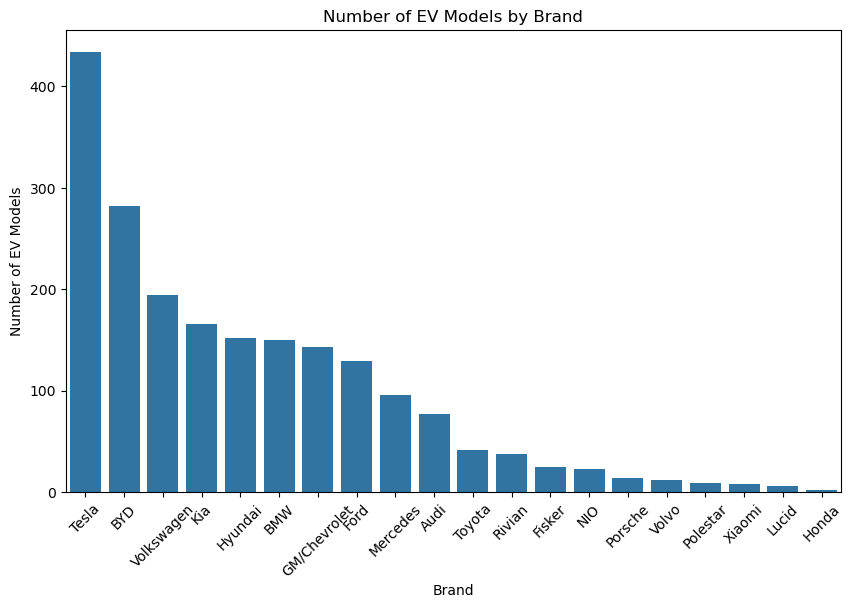

In [19]:
brand_count = data["brand"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=brand_count.index,
            y=brand_count.values)

plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Number of EV Models")
plt.title("Number of EV Models by Brand")

plt.show()

**Tesla has the highest number of EV models in the dataset, followed by BYD and Volkswagen. This suggests that Tesla currently has a strong presence and product diversity in the EV market.**

## Objective 2 : Relationship Between Battery Capacity and Driving Range

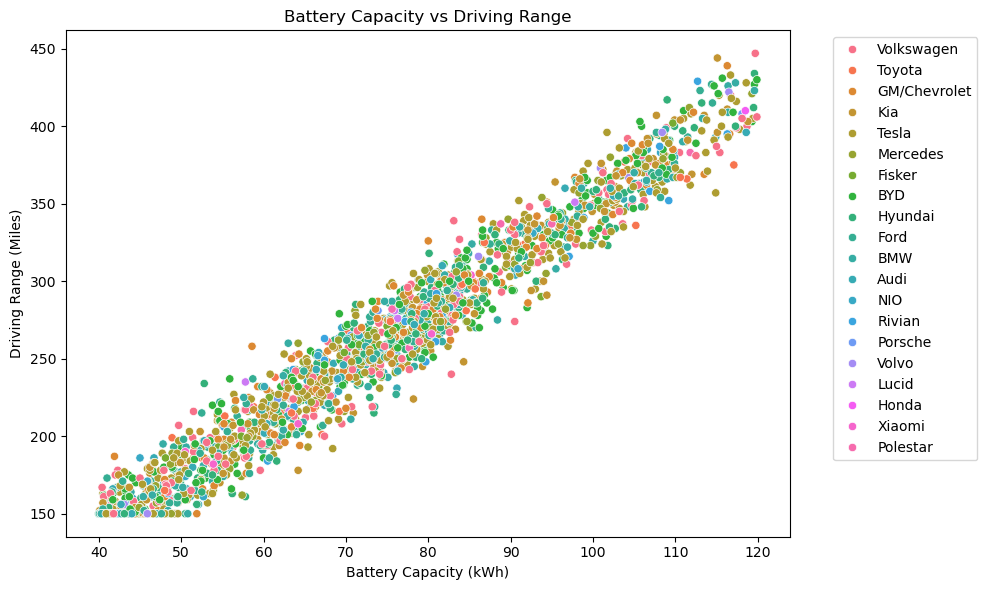

In [85]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="battery_capacity_kwh",
                y="range_miles",
                hue="brand",
                data=data)

plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Driving Range (Miles)")
plt.title("Battery Capacity vs Driving Range")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Vehicles with larger battery capacities generally achieve longer driving ranges. This shows a positive relationship between battery size and EV driving performance.**

## Objective 3: Price and Charging Speed Analysis

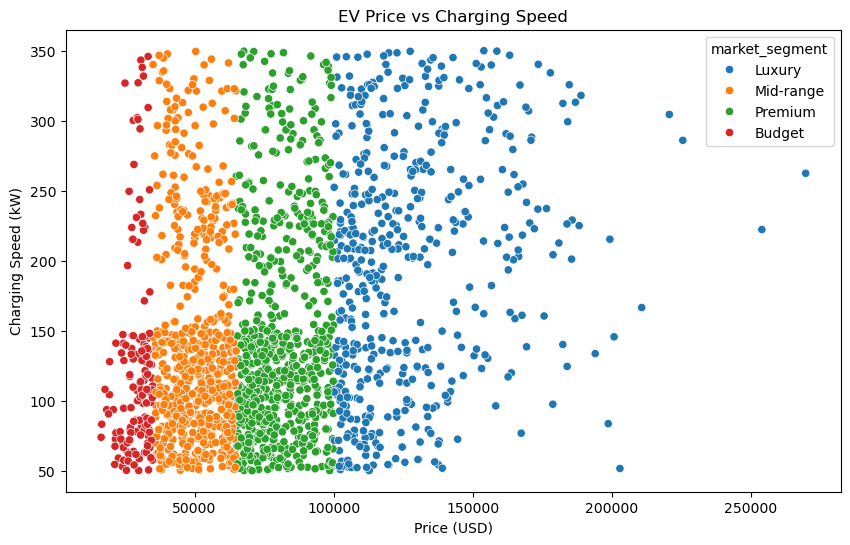

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="price_usd",
                y="charging_speed_kw",
                hue="market_segment",
                data=data)

plt.xlabel("Price (USD)")
plt.ylabel("Charging Speed (kW)")
plt.title("EV Price vs Charging Speed")

plt.show()

**Higher-priced EVs generally tend to support faster charging speeds. Premium and luxury EV models usually provide better charging technology compared to budget models.**

## Objective 4: Best Value Electric Vehicles

In [70]:
data["value_score"] = data["range_miles"] / data["price_usd"]

best_value = data.sort_values(by="value_score",
                              ascending=False)
best_value = best_value.reset_index(drop=True)
best_value[["brand",
            "model",
            "price_usd",
            "range_miles",
            "value_score"]].head(10)

,brand,model,price_usd,range_miles,value_score
0,BYD,Qin,17777.32,280.0,0.015750
1,BYD,Seagull,19470.99,291.0,0.014945
2,BYD,Seagull,16613.01,237.0,0.014266
3,BYD,Qin,27057.77,385.0,0.014229
4,BYD,Qin,21712.40,307.0,0.014139
5,BYD,Atto 3,26097.55,367.0,0.014063
6,BYD,Atto 3,25253.73,355.0,0.014057
7,BYD,Atto 3,31933.47,430.0,0.013465
8,BYD,Leaf 50X,25921.47,344.0,0.013271
9,BYD,Dolphin,19398.19,255.0,0.013146


**Some lower-priced EVs provide surprisingly strong driving ranges compared to their prices. This suggests that affordability does not always mean poor performance in the EV market.**

## Objective 5: Customer Rating Analysis

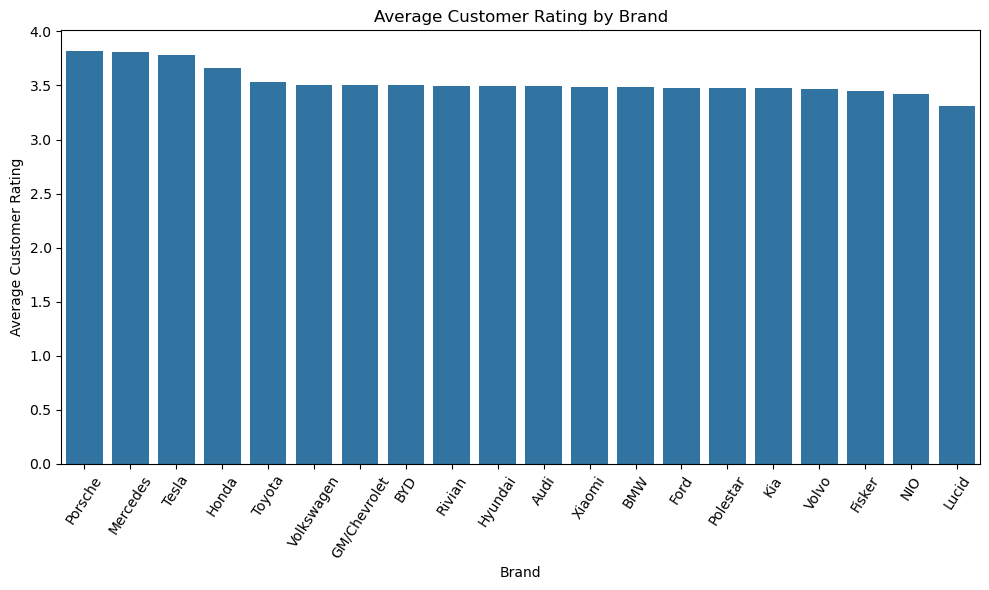

In [81]:
top_rating = data.groupby("brand")["customer_rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x=top_rating.index,
            y=top_rating.values)

plt.xticks(rotation=45)

plt.xlabel("Brand")
plt.ylabel("Average Customer Rating")
plt.title("Average Customer Rating by Brand")
plt.xticks(rotation=57)
plt.tight_layout()
plt.show()

**Several premium EV brands achieve higher average customer ratings, indicating strong customer satisfaction and product quality in the premium EV segment.**

## Conclusion

**Tesla and BYD dominate the EV market dataset with the highest number of models. 
Higher battery capacity is strongly associated with longer driving range. 
Customer ratings among EV brands are relatively similar, with luxury brands slightly outperforming others.**